In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [2]:
df = pd.read_csv(r"c:\Users\DELL\Downloads\skill-scarcity-index.csv")

In [3]:
df.head(1)

,snapshot_date,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
0,2026-07-12,ai,A/B Testing,115,4.7,1.0,3.9,2.0,49.2


In [4]:
df.shape

(1635, 9)

In [5]:
df.columns

Index(['snapshot_date', 'category', 'skill_name', 'demand_count', 'demand_pct',
       'median_days_open', 'salary_premium_pct', 'repost_rate_pct',
       'scarcity_score'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   snapshot_date       1635 non-null   str    
 1   category            1635 non-null   str    
 2   skill_name          1635 non-null   str    
 3   demand_count        1635 non-null   int64  
 4   demand_pct          1635 non-null   float64
 5   median_days_open    1385 non-null   float64
 6   salary_premium_pct  1260 non-null   float64
 7   repost_rate_pct     1635 non-null   float64
 8   scarcity_score      1635 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 154.2 KB


In [7]:
df.describe()

,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
count,1635.000000,1635.000000,1385.000000,1260.000000,1635.000000,1635.000000
mean,183.850765,4.061101,10.452708,5.001508,9.467401,41.062691
std,335.364311,6.844956,18.208752,45.913586,10.359433,21.082768
min,10.000000,0.100000,0.000000,-71.100000,0.000000,0.000000
25%,23.000000,0.700000,0.000000,-30.000000,0.000000,27.600000
50%,57.000000,1.600000,1.000000,-5.250000,6.800000,40.400000
75%,174.500000,4.250000,12.000000,31.125000,15.400000,56.550000
max,2904.000000,82.300000,82.000000,219.500000,83.300000,100.000000


In [8]:
df.isnull().sum()

snapshot_date           0
category                0
skill_name              0
demand_count            0
demand_pct              0
median_days_open      250
salary_premium_pct    375
repost_rate_pct         0
scarcity_score          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["category"].value_counts()

category
engineering    427
data           324
ai             271
devops         257
product        201
security       155
Name: count, dtype: int64

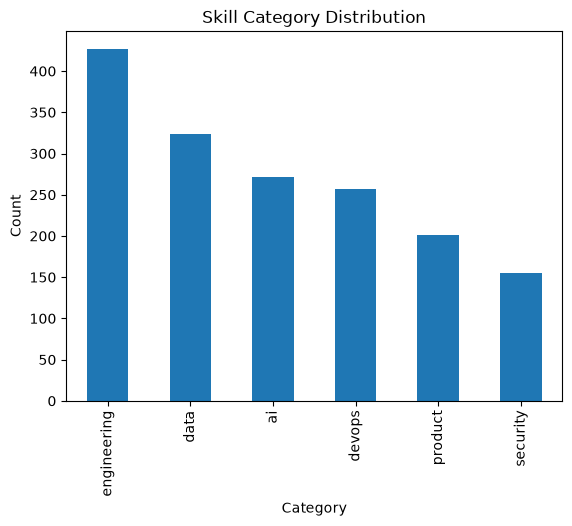

In [11]:
df["category"].value_counts().plot(kind="bar")

plt.title("Skill Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [12]:
df = df.drop(columns=["snapshot_date", "skill_name"])

In [13]:
df.head(1)

,category,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
0,ai,115,4.7,1.0,3.9,2.0,49.2


In [14]:
df["median_days_open"] = df["median_days_open"].fillna(
    df["median_days_open"].median()
)

df["salary_premium_pct"] = df["salary_premium_pct"].fillna(
    df["salary_premium_pct"].median()
)

In [15]:
df.isnull().sum()

category              0
demand_count          0
demand_pct            0
median_days_open      0
salary_premium_pct    0
repost_rate_pct       0
scarcity_score        0
dtype: int64

In [16]:
X = df.drop(columns="category")
y = df["category"]

In [17]:
X.head()

,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
0,115,4.7,1.0,3.90,2.0,49.2
1,63,2.6,1.0,42.50,14.0,62.9
2,153,6.3,1.0,45.50,5.9,72.0
3,32,1.3,1.0,-5.25,0.0,0.0
4,54,2.2,9.0,-38.70,16.2,57.2


In [18]:
y.head()

0    ai
1    ai
2    ai
3    ai
4    ai
Name: category, dtype: str

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1308, 6)
Testing Features: (327, 6)
Training Target: (1308,)
Testing Target: (327,)


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print(f"K = {k} --> Accuracy = {accuracy:.4f}")

K = 3 --> Accuracy = 0.5199
K = 5 --> Accuracy = 0.4954
K = 7 --> Accuracy = 0.4832
K = 9 --> Accuracy = 0.5046


In [23]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['ai','data','devops','engineering','product','security']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['demand_count','demand_pct','median_days_open','salary_premium_pct', 'repost_rate_pct','scarcity_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [24]:
y_pred = pipeline.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5198776758409785


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          ai       0.38      0.61      0.47        54
        data       0.48      0.58      0.53        65
      devops       0.34      0.27      0.30        52
 engineering       0.73      0.61      0.67        85
     product       0.69      0.45      0.55        40
    security       0.65      0.48      0.56        31

    accuracy                           0.52       327
   macro avg       0.55      0.50      0.51       327
weighted avg       0.55      0.52      0.52       327



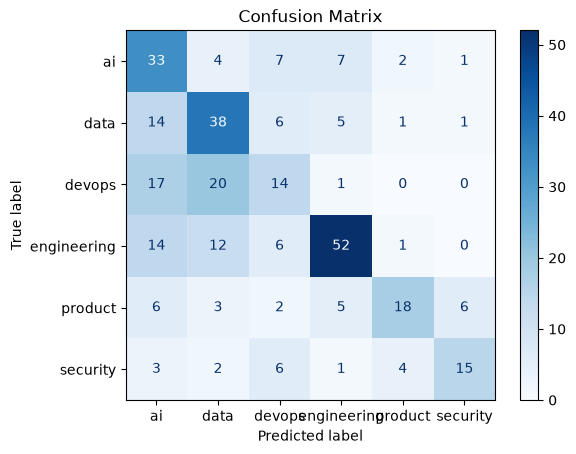

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_
)

display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [29]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    pipeline,
    "models/skill_category_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [30]:
loaded_pipeline = joblib.load(
    "models/skill_category_pipeline.pkl"
)

print(loaded_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=3))])


In [31]:
sample = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample)

print("Predicted Category:", prediction[0])
print("Actual Category:", y_test.iloc[0])

Predicted Category: security
Actual Category: security
